In [1]:
import xarray as xr
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.patches as mpatches
from tqdm import tqdm

In [2]:
from dask.distributed import Client
client = Client(n_workers=4, threads_per_worker=3, memory_limit=15e9)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 12,Total memory: 55.88 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38033,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33485,Total threads: 3
Dashboard: http://127.0.0.1:43871/status,Memory: 13.97 GiB
Nanny: tcp://127.0.0.1:35099,


2026-02-19 13:34:13,979 - distributed.scheduler - ERROR - Task 'finalize-hlgfinalizecompute-2433f0371d6b41768d01334ab103d573' has 37.35 GiB worth of input dependencies, but worker tcp://127.0.0.1:33485 has memory_limit set to 13.97 GiB. It seems like you called client.compute() on a huge collection. Consider writing to distributed storage or slicing/reducing first.
2026-02-19 13:35:11,561 - distributed.scheduler - ERROR - Task 'finalize-hlgfinalizecompute-487619667ae74f01a9e7b62464932b54' has 37.35 GiB worth of input dependencies, but worker tcp://127.0.0.1:45649 has memory_limit set to 13.97 GiB. It seems like you called client.compute() on a huge collection. Consider writing to distributed storage or slicing/reducing first.


In [3]:
!echo dask dashboard :D
!echo https://jupyterhub.dkrz.de/user/$USER/levante-spawner-preset/proxy/8787/status

dask dashboard :D
https://jupyterhub.dkrz.de/user/b383184/levante-spawner-preset/proxy/8787/status


In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [63]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

def anomaly(data):
    """Compute anomalies by removing the seasonal cycle (monthly climatology)."""
    clim = seasonality(data)
    anom = data.groupby('time.month') - clim
    return anom

In [6]:
sal_ = xr.open_dataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/tracers/S_1993-01c.nc',chunks={'time_counter':-1, 'deptht': 7, 'y': 250, 'x': 600},
                        ).isel(deptht=slice(0, 7))
sal_ = sal_.rename({'vosaline':'sal','time_counter':'time','deptht':'depth'}).assign_coords({
    'lat': sal_.nav_lat.isel(x=0).load(),
    'lon': sal_.nav_lon.isel(y=0).load()})\
    .drop_vars({'nav_lon','nav_lat'})\
        .swap_dims({'x':'lon','y':'lat'}).drop_vars({'x','y'})
# sal = sal.assign_coords({
#     'lat': sal.nav_lat.isel(x=0).load(),
#     'lon': sal.nav_lon.isel(y=0).load()
# })
# sal = sal.drop_vars({'nav_lon','nav_lat'})
# sal = sal.swap_dims({'x':'lon','y':'lat'})
# sal = sal.drop_vars({'x','y'})
sal_ = sal_.load()
sal_

<xarray.Dataset> Size: 546MB
Dimensions:  (time: 31, depth: 7, lat: 499, lon: 1260)
Coordinates:
  * time     (time) datetime64[ns] 248B 1993-01-01T12:00:00 ... 1993-01-31T12...
  * depth    (depth) float32 28B 0.494 1.541 2.646 3.819 5.078 6.441 7.93
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
Data variables:
    sal      (time, depth, lat, lon) float32 546MB 35.78 35.77 35.78 ... nan nan
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Fri Nov 07 01:00:33 2025: cdo setmissval,nan S_1993-01.nc /...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

In [7]:
dz = np.diff(sal_['depth'].values, prepend=0)
dz = xr.DataArray(dz, dims='depth', coords={'depth': sal_['depth']})
# dz = dz.rename({'depth':'depth'})
dz

<xarray.DataArray (depth: 7)> Size: 56B
array([0.49402538, 1.04735002, 1.10429311, 1.17382622, 1.25872898,
       1.36239052, 1.48894596])
Coordinates:
  * depth    (depth) float32 28B 0.494 1.541 2.646 3.819 5.078 6.441 7.93

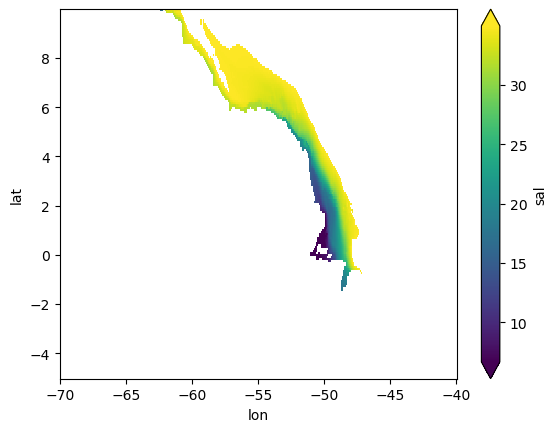

In [8]:
sali = sal_.sal.weighted(dz).mean('depth').mean('time')
sali.where(sali<=35).sel(lat=slice(-5,10),lon=slice(-70,-40)).plot(robust=True)

In [9]:
sal = xr.open_mfdataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/tracers/S_*.nc',chunks={'time_counter':-1, 'deptht': 7, 'y': 250, 'x': 600},
                        ).isel(deptht=slice(0, 7))
sal = sal.rename({'vosaline':'sal','time_counter':'time','deptht':'depth'}).assign_coords({
    'lat': sal.nav_lat.isel(x=0).load(),
    'lon': sal.nav_lon.isel(y=0).load()})\
    .drop_vars({'nav_lon','nav_lat'})\
        .swap_dims({'x':'lon','y':'lat'}).drop_vars({'x','y'})
sal

<xarray.Dataset> Size: 140GB
Dimensions:  (time: 7973, depth: 7, lat: 499, lon: 1260)
Coordinates:
  * time     (time) datetime64[ns] 64kB 1993-01-01T12:00:00 ... 2014-12-31T12...
  * depth    (depth) float32 28B 0.494 1.541 2.646 3.819 5.078 6.441 7.93
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
Data variables:
    sal      (time, depth, lat, lon) float32 140GB dask.array<chunksize=(31, 7, 250, 600), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Fri Nov 07 01:00:33 2025: cdo setmissval,nan S_1993-01.nc /...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

In [16]:
sal_meso = sal.sal.weighted(dz).mean('depth')
sal_meso = sal_meso.chunk({'time': 30})
sal_meso

<xarray.DataArray 'sal' (time: 7973, lat: 499, lon: 1260)> Size: 40GB
dask.array<rechunk-merge, shape=(7973, 499, 1260), dtype=float64, chunksize=(30, 250, 600), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 64kB 1993-01-01T12:00:00 ... 2014-12-31T12...
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917

In [17]:
# sal_meso.drop_encoding().to_zarr('Sal_meso_0_7m.zarr', mode='w')

In [76]:
sali = sal.sal.weighted(dz).mean('depth').resample(time='MS').mean()
sali

<xarray.DataArray 'sal' (time: 264, lat: 499, lon: 1260)> Size: 1GB
dask.array<where, shape=(264, 499, 1260), dtype=float64, chunksize=(1, 250, 600), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01

In [77]:
# sali.drop_encoding().to_netcdf('Sal_m_0_7m.nc')
# sali.drop_encoding().to_zarr('Sal_m_0_7m.zarr', mode='w')

## Plotting the salinity

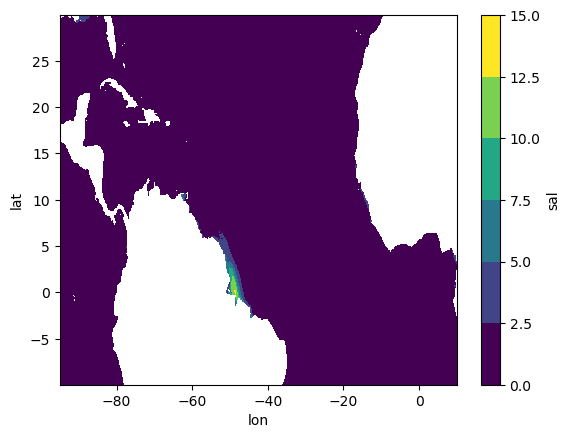

In [3]:
# xr.open_zarr('Sal_m_0_7m.zarr').to_netcdf('Sal_m_0_7m.nc')
aa = xr.open_dataset('Sal_m_0_7m.nc').compute()
aa.std('time').sal.plot.contourf()

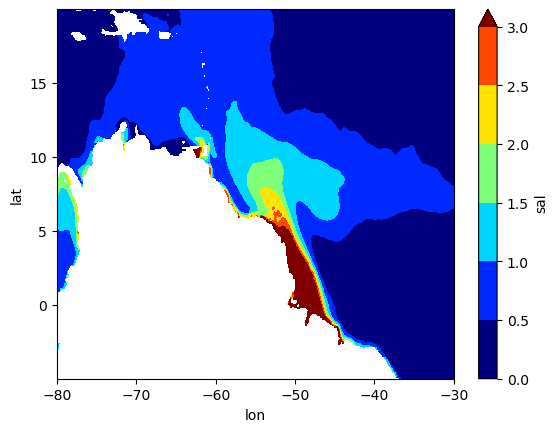

In [4]:
aa.std('time').sel(lat=slice(-5,20),lon=slice(-80,-30)).sal.plot.contourf(robust=True,cmap='jet')

### Replicating Liang et al., 2020
* ARP Area 15N-0N, 65W-49W

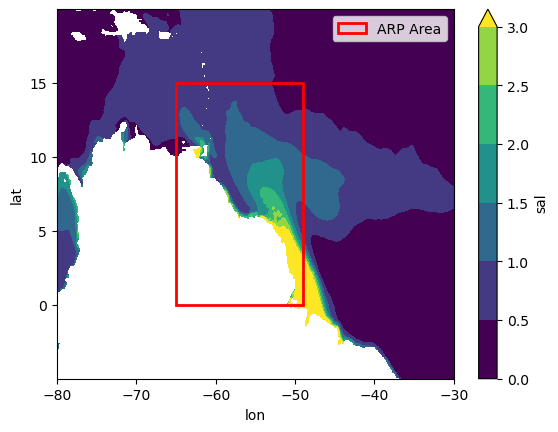

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Your plot
aa.std('time').sel(lat=slice(-5,20), lon=slice(-80,-30)).sal.plot.contourf(robust=True)

# Add the ARP box
ax = plt.gca()
rect = mpatches.Rectangle(
    xy=(-65, 0),           # bottom-left corner (lon, lat)
    width=16,              # 65W to 49W = 16 degrees
    height=15,             # 0N to 15N = 15 degrees
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    label='ARP Area'
)
ax.add_patch(rect)
ax.legend()

plt.show()

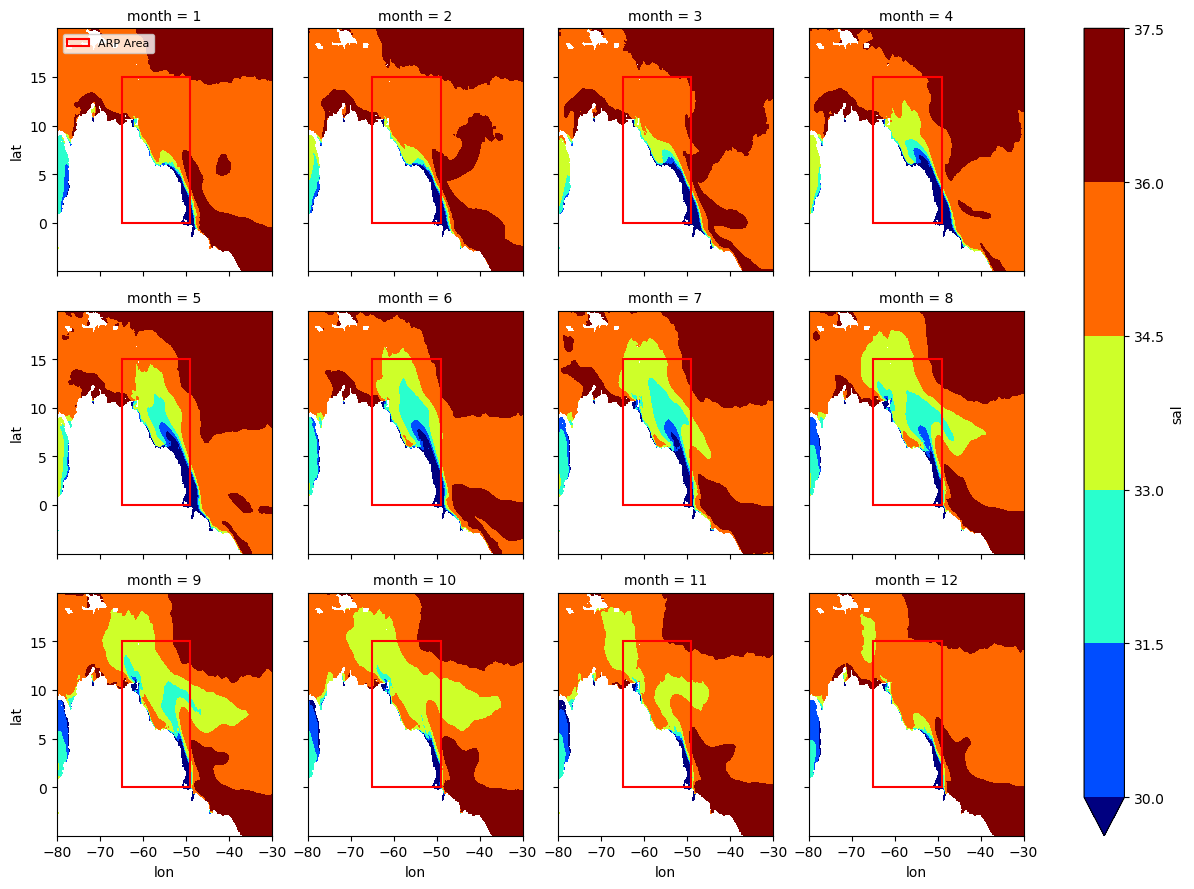

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create the facet plot
g = seasonality(aa.sel(lat=slice(-5, 20), lon=slice(-80, -30)).sal).plot.contourf(
    x="lon", y="lat", col="month", col_wrap=4, cmap='jet', robust=True
)

# Loop over all axes and add the rectangle
for ax in g.axs.flat:
    rect = mpatches.Rectangle(
        xy=(-65, 0),
        width=16,
        height=15,
        linewidth=1.5,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

# Add legend to the first subplot (optional)
g.axs.flat[0].legend(['ARP Area'], loc='upper left', fontsize=8)

# plt.tight_layout()
plt.show()

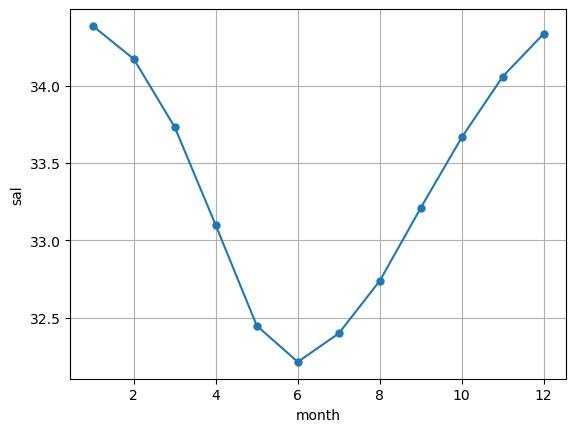

In [7]:
seasonality(aa.sel(lat=slice(0,15), lon=slice(-65,-49)).sal)\
    .mean(dim=('lon','lat')).plot(marker='.',markersize=10)
plt.grid()

### My ARP definition

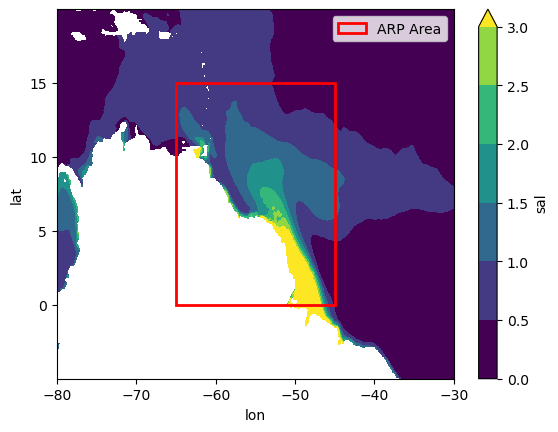

In [8]:
# Your plot
aa.std('time').sel(lat=slice(-5,20), lon=slice(-80,-30)).sal.plot.contourf(robust=True)

# Add the ARP box
ax = plt.gca()
rect = mpatches.Rectangle(
    xy=(-65, 0),           # bottom-left corner (lon, lat)
    width=20,              # 65W to 49W = 16 degrees
    height=15,             # 0N to 15N = 15 degrees
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    label='ARP Area'
)
ax.add_patch(rect)
ax.legend()

plt.show()

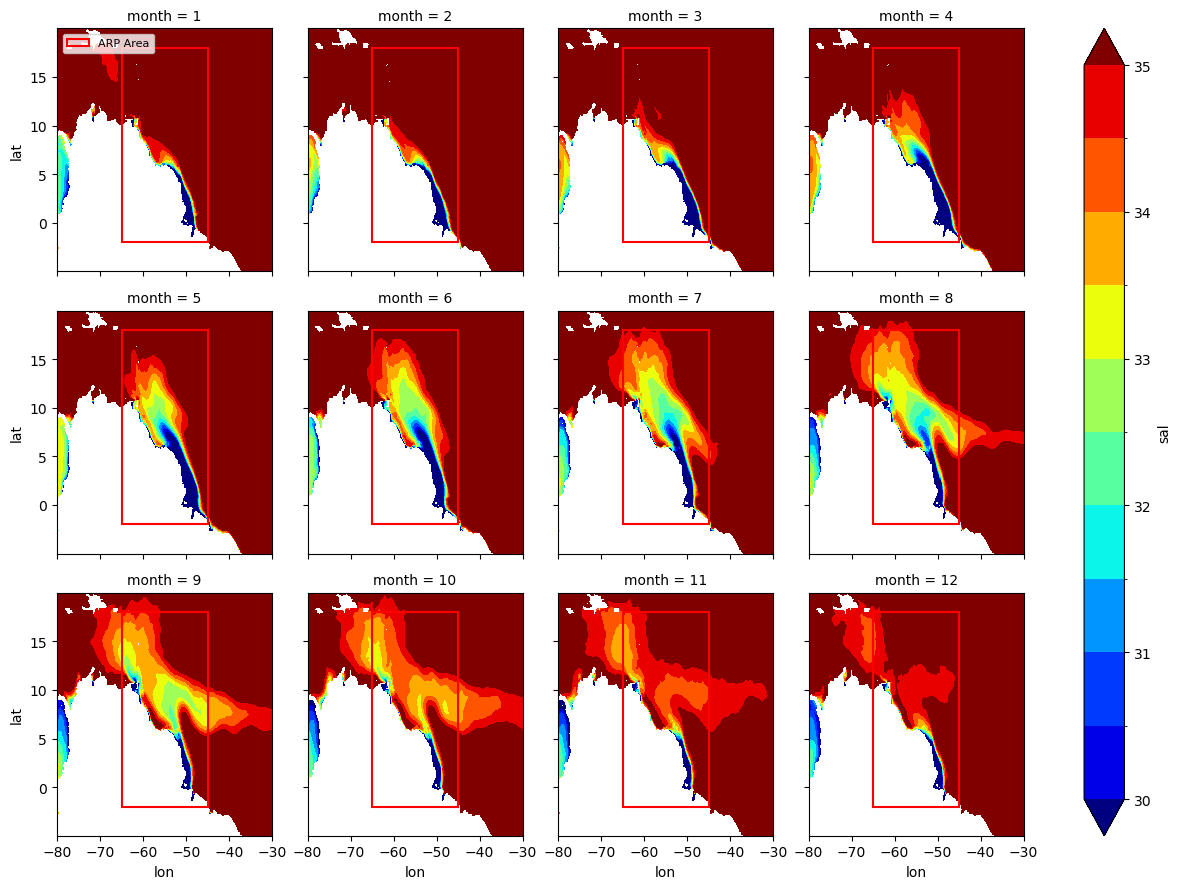

In [9]:
# Create the facet plot
g = seasonality(aa.sel(lat=slice(-5,20), lon=slice(-80,-30)).sal).plot.contourf(
    x="lon", y="lat", col="month", col_wrap=4, cmap='jet',levels=11,vmax=35,vmin=30
)

# Loop over all axes and add the rectangle
for ax in g.axs.flat:
    rect = mpatches.Rectangle(
        xy=(-65, -2),
        width=20,
        height=20,
        linewidth=1.5,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

# Add legend to the first subplot (optional)
g.axs.flat[0].legend(['ARP Area'], loc='upper left', fontsize=8)

# plt.tight_layout()
plt.show()

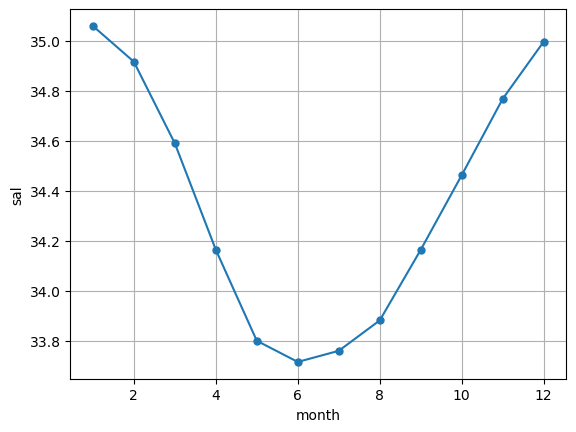

In [10]:
seasonality(aa.sel(lat=slice(0,18), lon=slice(-65,-45)).sal)\
    .mean(dim=('lon','lat')).plot(marker='.',markersize=10)
plt.grid()

#### Salinity Anomaly

In [11]:
s_anom = anomaly(aa)
s_anom =s_anom.assign_coords(year = s_anom.time.dt.year)
s_anom

<xarray.Dataset> Size: 1GB
Dimensions:  (lat: 499, lon: 1260, time: 264)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01
    month    (time) int64 2kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
    year     (time) int64 2kB 1993 1993 1993 1993 1993 ... 2014 2014 2014 2014
Data variables:
    sal      (time, lat, lon) float64 1GB 0.2488 0.2392 0.2302 ... nan nan nan

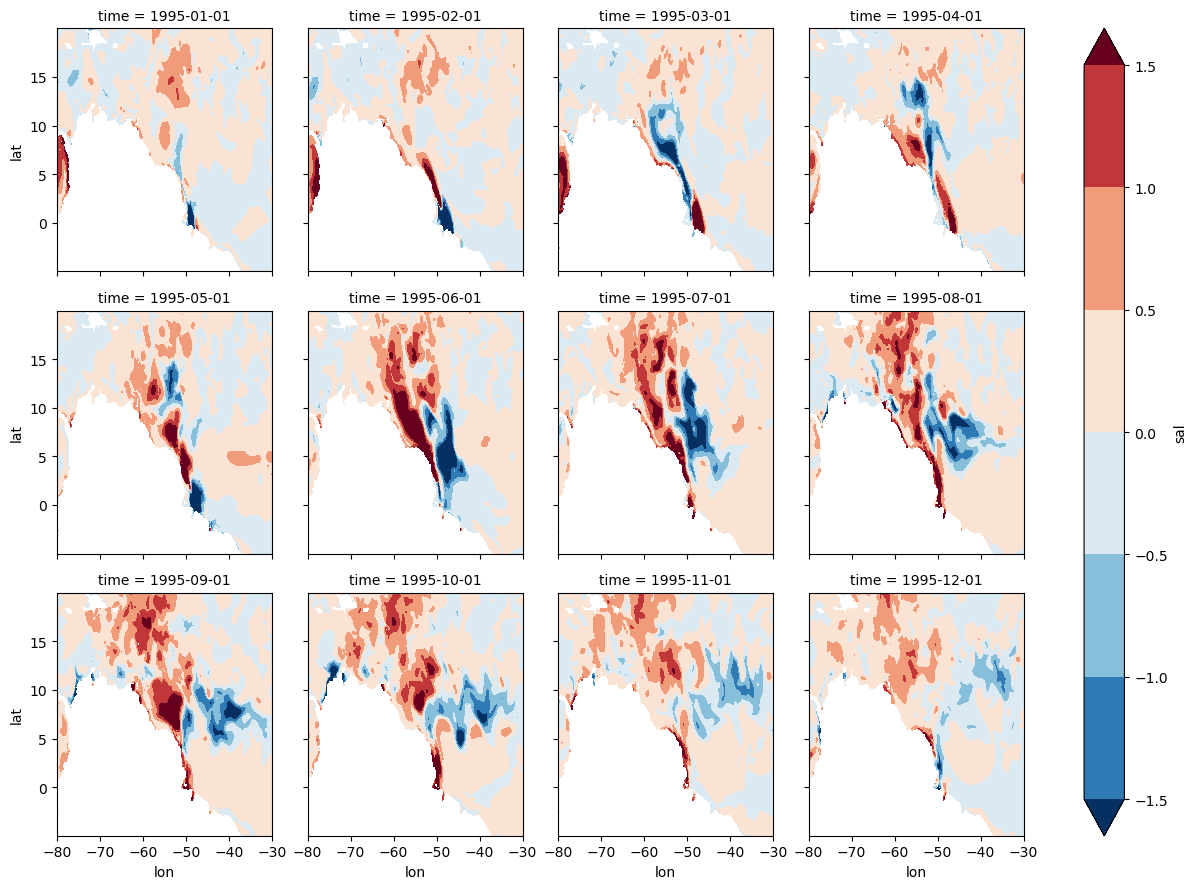

In [12]:
s_anom.sel(time=s_anom.year == 1995).sal.sel(lat=slice(-5,20), lon=slice(-80,-30))\
    .plot.contourf(x='lon',y='lat',col='time',col_wrap=4,robust=True,cmap='RdBu_r')

### Mesoscale

In [5]:
sal_meso = xr.open_zarr('Sal_meso_0_7m.zarr')\
    .assign_coords(year = sal_meso.time.dt.year, month=sal_meso.time.dt.month)

sal_meso

<xarray.Dataset> Size: 40GB
Dimensions:  (lat: 499, lon: 1260, time: 7973)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * time     (time) datetime64[ns] 64kB 1993-01-01T12:00:00 ... 2014-12-31T12...
    year     (time) int64 64kB 1993 1993 1993 1993 1993 ... 2014 2014 2014 2014
    month    (time) int64 64kB 1 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12 12 12
Data variables:
    sal      (time, lat, lon) float64 40GB dask.array<chunksize=(30, 250, 600), meta=np.ndarray>

In [65]:
sal_meso_anom = anomaly(sal_meso)
sal_meso_anom 

<xarray.Dataset> Size: 40GB
Dimensions:  (lat: 499, lon: 1260, time: 7973)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * time     (time) datetime64[ns] 64kB 1993-01-01T12:00:00 ... 2014-12-31T12...
    year     (time) int64 64kB 1993 1993 1993 1993 1993 ... 2014 2014 2014 2014
    month    (time) int64 64kB 1 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12 12 12
Data variables:
    sal      (time, lat, lon) float64 40GB dask.array<chunksize=(1, 250, 600), meta=np.ndarray>

In [61]:
sal_April = sal_meso.sel(time=(sal_meso.year == 1995)&(sal_meso.month == 4)).compute()
sal_April = sal_April.isel(time=slice(1, None))
sal_April

<xarray.Dataset> Size: 146MB
Dimensions:  (lat: 499, lon: 1260, time: 29)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * time     (time) datetime64[ns] 232B 1995-04-02T12:00:00 ... 1995-04-30T12...
    year     (time) int64 232B 1995 1995 1995 1995 1995 ... 1995 1995 1995 1995
    month    (time) int64 232B 4 4 4 4 4 4 4 4 4 4 4 4 ... 4 4 4 4 4 4 4 4 4 4 4
Data variables:
    sal      (time, lat, lon) float64 146MB 35.27 35.27 35.28 ... nan nan nan

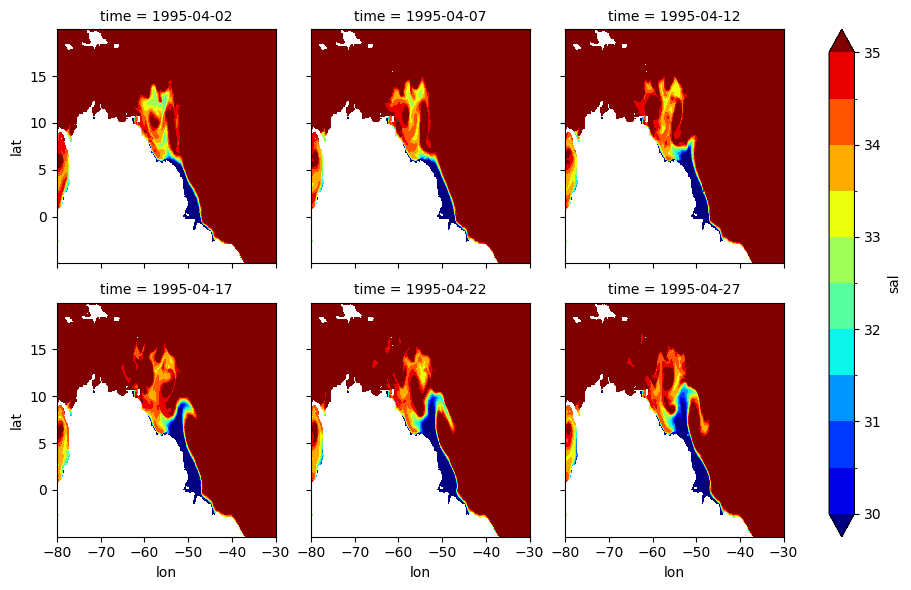

In [62]:
sal_April.resample(time='5D').mean().sel(lat=slice(-5,20), lon=slice(-80,-30)).sal\
    .plot.contourf(x='lon',y='lat',col='time',col_wrap=3,cmap='jet',levels=11,vmin=30,vmax=35)

Text(0.5, 1.0, '1995-04-17')

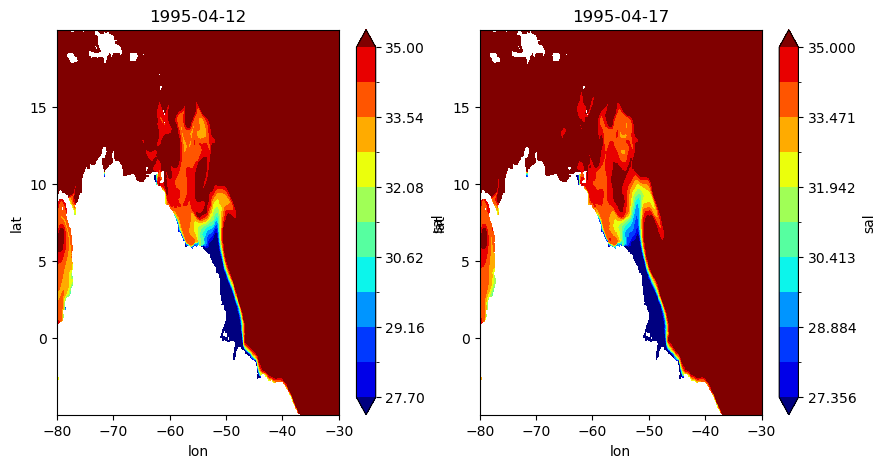

In [60]:
fig,ax = plt.subplots(1,2,figsize=(10,5))

sal_April.sel(time=slice('1995-04-12','1995-04-22')).sel(lat=slice(-5,20), lon=slice(-80,-30))\
    .sal.mean(dim='time').plot.contourf(robust=True,cmap='jet',levels=11,vmax=35,ax=ax[0])

sal_April.sel(time=slice('1995-04-17','1995-04-27')).sel(lat=slice(-5,20), lon=slice(-80,-30))\
    .sal.mean(dim='time').plot.contourf(robust=True,cmap='jet',levels=11,vmax=35,ax=ax[1])

ax[0].set_title('1995-04-12')
ax[1].set_title('1995-04-17')

#### Now the Meso anomaly

In [67]:
sal_anom_April = sal_meso_anom.sel(time=(sal_meso_anom.year == 1995)&(sal_meso_anom.month == 4)).compute()
sal_anom_April = sal_anom_April.isel(time=slice(1, None))
sal_anom_April
# sal_meso_anom 

<xarray.Dataset> Size: 146MB
Dimensions:  (lat: 499, lon: 1260, time: 29)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * time     (time) datetime64[ns] 232B 1995-04-02T12:00:00 ... 1995-04-30T12...
    year     (time) int64 232B 1995 1995 1995 1995 1995 ... 1995 1995 1995 1995
    month    (time) int64 232B 4 4 4 4 4 4 4 4 4 4 4 4 ... 4 4 4 4 4 4 4 4 4 4 4
Data variables:
    sal      (time, lat, lon) float64 146MB -0.1587 -0.1581 -0.1566 ... nan nan

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


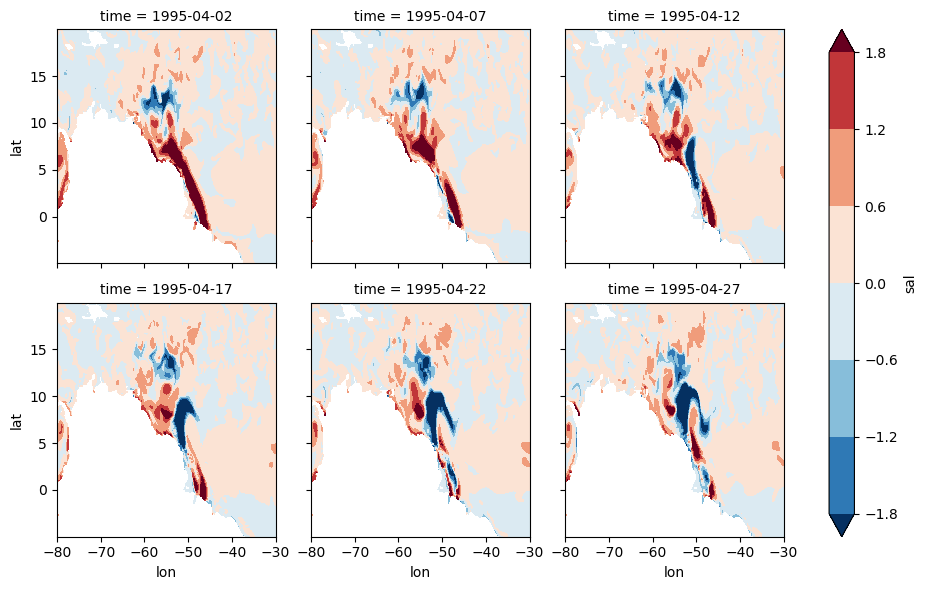

In [71]:
sal_anom_April.resample(time='5D').mean().sel(lat=slice(-5,20), lon=slice(-80,-30)).sal\
    .plot.contourf(x='lon',y='lat',col='time',col_wrap=3,cmap='RdBu_r',robust=True)

Text(0.5, 1.0, '1995-04-17')

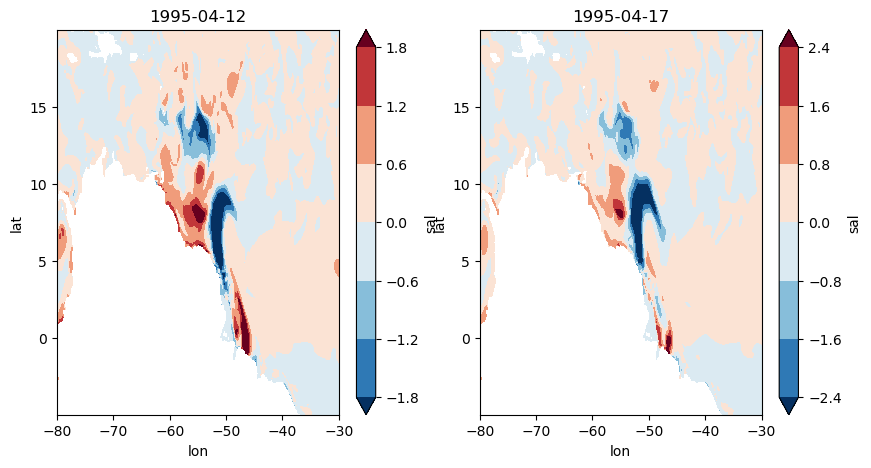

In [74]:
fig,ax = plt.subplots(1,2,figsize=(10,5))

sal_anom_April.sel(time=slice('1995-04-12','1995-04-22')).sel(lat=slice(-5,20), lon=slice(-80,-30))\
    .sal.mean(dim='time').plot.contourf(robust=True,cmap='RdBu_r',ax=ax[0])

sal_anom_April.sel(time=slice('1995-04-17','1995-04-27')).sel(lat=slice(-5,20), lon=slice(-80,-30))\
    .sal.mean(dim='time').plot.contourf(robust=True,cmap='RdBu_r',ax=ax[1])

ax[0].set_title('1995-04-12')
ax[1].set_title('1995-04-17')

In [77]:
sal_anom_std = sal_meso_anom.std('time').compute()
sal_anom_std

<xarray.Dataset> Size: 5MB
Dimensions:  (lat: 499, lon: 1260)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
Data variables:
    sal      (lat, lon) float64 5MB 0.2144 0.2131 0.2118 0.2108 ... nan nan nan

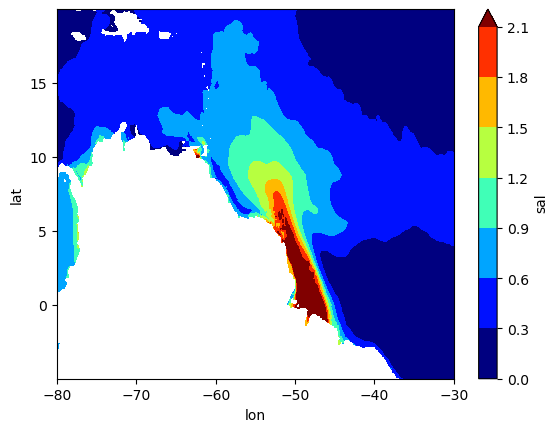

In [83]:
sal_anom_std.sal.sel(lat=slice(-5,20), lon=slice(-80,-30)).\
    plot.contourf(robust=True,cmap='jet')

In [97]:
april_std = sal_meso_anom.sel(time=sal_meso_anom.month == 4).groupby('year').std().compute()
april_std 

<xarray.Dataset> Size: 111MB
Dimensions:  (year: 22, lat: 499, lon: 1260)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * year     (year) int64 176B 1993 1994 1995 1996 1997 ... 2011 2012 2013 2014
Data variables:
    sal      (year, lat, lon) float64 111MB 0.07407 0.07486 0.07469 ... nan nan

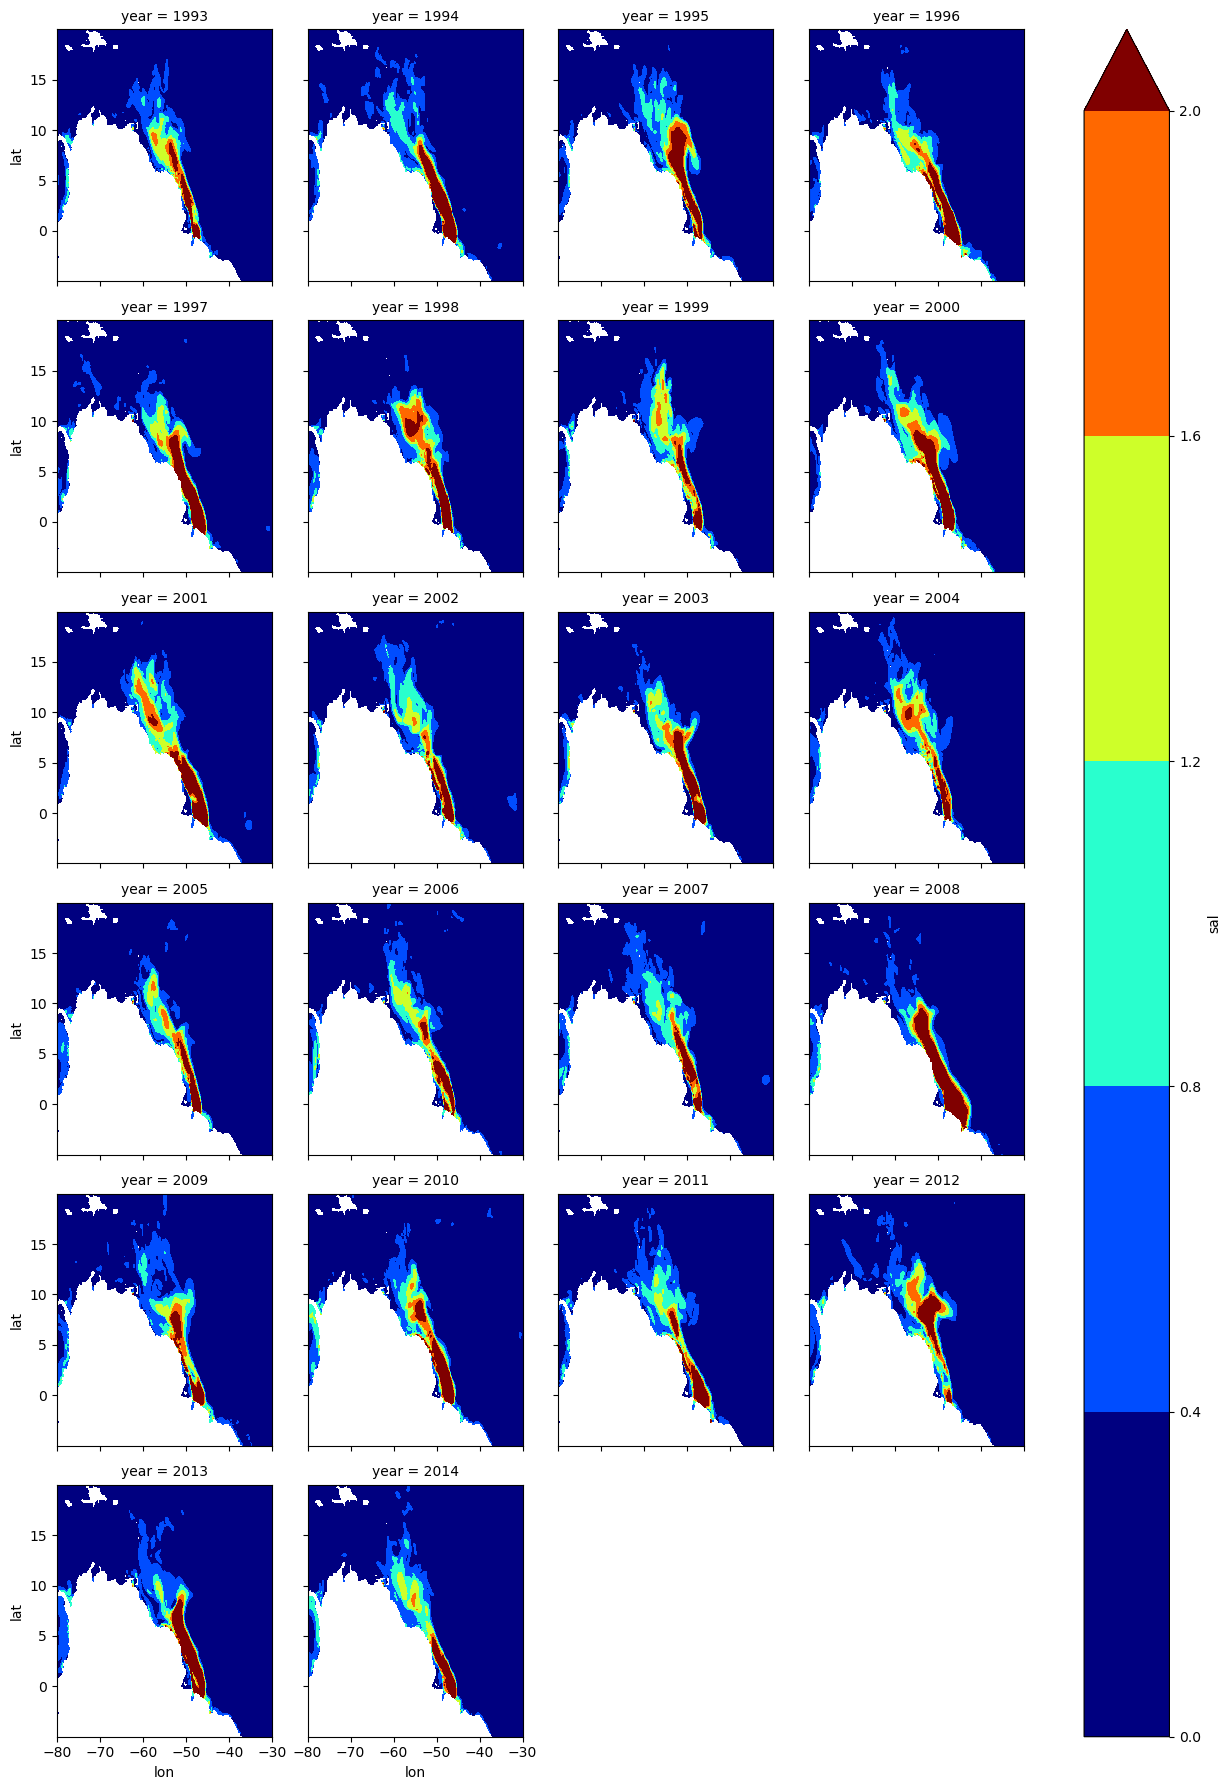

In [100]:
april_std.sal.sel(lat=slice(-5,20), lon=slice(-80,-30)).\
    plot.contourf(x='lon',y='lat',col='year',col_wrap=4,robust=True,cmap='jet')

### Seasonal cycles Comparison

In [11]:
EKE = xr.open_dataset('EKE_monthly.nc').compute()
EKE = EKE.rename({'__xarray_dataarray_variable__':'EKE'})
EKE

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 264, lat: 499, lon: 1260)
Coordinates:
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
Data variables:
    EKE      (time, lat, lon) float64 1GB nan nan nan nan ... nan nan nan nan

In [12]:
RMS = xr.open_dataset('RMS_d_weighted.nc').compute()


Text(0.5, 1.0, 'Speed RM')

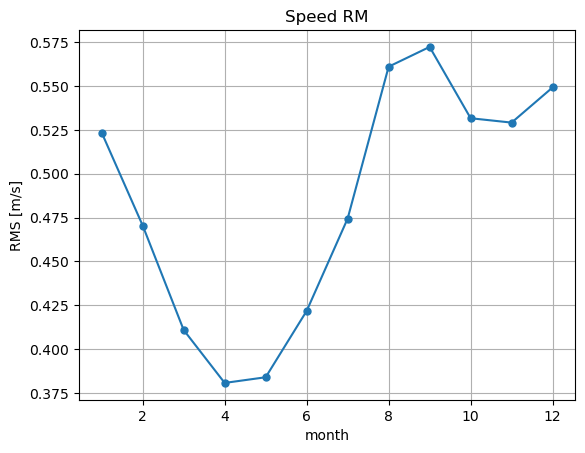

In [13]:
seasonality(RMS).sel(lon=slice(-55,-40), lat=slice(2,10)) \
    .RMS.mean(dim=('lat','lon')).rename('RMS [m/s]')\
    .plot(linestyle='-',marker='.',markersize=10)
plt.grid()
plt.title('Speed RM') 

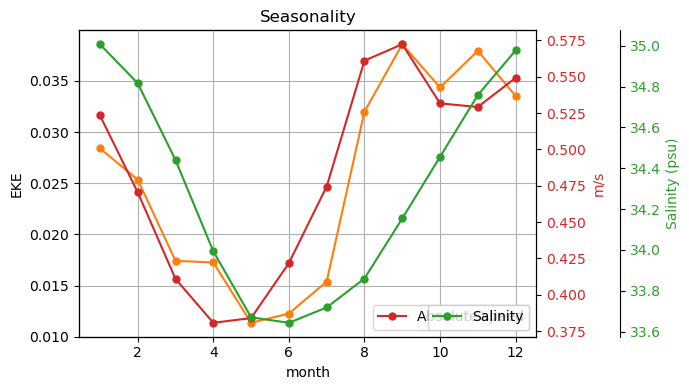

In [21]:
fig, ax1 = plt.subplots(figsize=(7, 4))

# Primary y-axis: EKE
# seasonality(EKE).EKE.sel(lon=slice(-55,-51), lat=slice(7,10)).mean(dim=('lon','lat')).plot(
#     ax=ax1, label='NBC dippner', color='C0'
# )
seasonality(EKE).EKE.sel(lon=slice(-55,-40), lat=slice(5,10)).mean(dim=('lon','lat')).plot(
    ax=ax1, label='EKE NBC', color='C1',marker='.', markersize=10
)

ax1.set_ylabel('EKE', color='k')
ax1.tick_params(axis='y', labelcolor='k')
ax1.legend(loc='lower right')
ax1.grid(True)

# Secondary y-axis: RMS
ax2 = ax1.twinx()
seasonality(RMS).sel(lon=slice(-55,-40), lat=slice(2,10)).RMS.mean(dim=('lat','lon')).plot(
    ax=ax2, linestyle='-', marker='.', markersize=10, color='C3', label='Absolute speed'
)

ax2.set_ylabel('m/s', color='C3')
ax2.tick_params(axis='y', labelcolor='C3')
ax2.legend(loc='lower right')

# Third y-axis: Salinity (offset to the right)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # Offset the third axis

seasonality(aa.sel(lat=slice(-2,18), lon=slice(-65,-45)).sal).mean(dim=('lon','lat')).plot(
    ax=ax3, marker='.', markersize=10, color='C2', label='Salinity'
)

ax3.set_ylabel('Salinity (psu)', color='C2')
ax3.tick_params(axis='y', labelcolor='C2')
ax3.legend(loc='lower right')

plt.title('Seasonality')
plt.tight_layout()
plt.show()

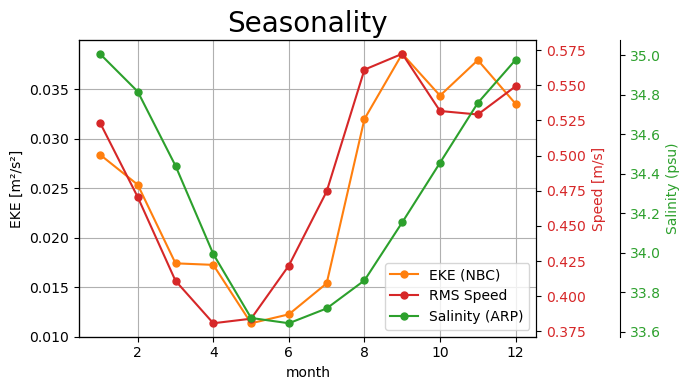

In [29]:
fig, ax1 = plt.subplots(figsize=(7, 4))

# Primary y-axis: EKE
line1, = seasonality(EKE).EKE.sel(lon=slice(-55,-40), lat=slice(5,10)).mean(dim=('lon','lat')).plot(
    ax=ax1, label='EKE (NBC)', color='C1', marker='.', markersize=10
)

ax1.set_ylabel('EKE [m²/s²]', color='k')
ax1.tick_params(axis='y', labelcolor='k')
ax1.grid(True)

# Secondary y-axis: RMS
ax2 = ax1.twinx()
line2, = seasonality(RMS).sel(lon=slice(-55,-40), lat=slice(2,10)).RMS.mean(dim=('lat','lon')).plot(
    ax=ax2, linestyle='-', marker='.', markersize=10, color='C3', label='RMS Speed'
)

ax2.set_ylabel('Speed [m/s]', color='C3')
ax2.tick_params(axis='y', labelcolor='C3')

# Third y-axis: Salinity (offset to the right)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))

line3, = seasonality(aa.sel(lat=slice(-2,18), lon=slice(-65,-45)).sal).mean(dim=('lon','lat')).plot(
    ax=ax3, marker='.', markersize=10, color='C2', label='Salinity (ARP)'
)

ax3.set_ylabel('Salinity (psu)', color='C2')
ax3.tick_params(axis='y', labelcolor='C2')

# Combine all legends into one
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower right')

plt.title('Seasonality',fontsize=20)
plt.tight_layout()
plt.show()

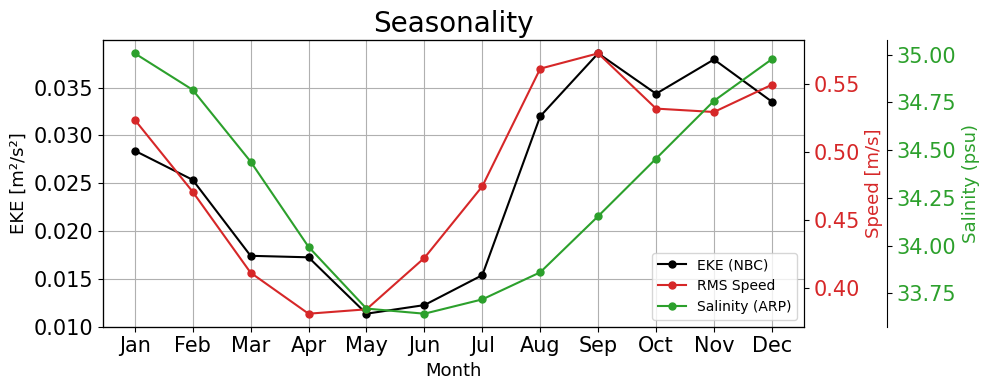

In [40]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 4))

# Primary y-axis: EKE
line1, = seasonality(EKE).EKE.sel(lon=slice(-55,-40), lat=slice(5,10)).mean(dim=('lon','lat')).plot(
    ax=ax1, label='EKE (NBC)', color='k', marker='.', markersize=10
)

ax1.set_ylabel('EKE [m²/s²]', color='k')
ax1.tick_params(axis='y', labelcolor='k')
ax1.grid(True)

# Secondary y-axis: RMS
ax2 = ax1.twinx()
line2, = seasonality(RMS).sel(lon=slice(-55,-40), lat=slice(2,10)).RMS.mean(dim=('lat','lon')).plot(
    ax=ax2, linestyle='-', marker='.', markersize=10, color='C3', label='RMS Speed'
)

ax2.set_ylabel('Speed [m/s]', color='C3')
ax2.tick_params(axis='y', labelcolor='C3')

# Third y-axis: Salinity (offset to the right)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))

line3, = seasonality(aa.sel(lat=slice(-2,18), lon=slice(-65,-45)).sal).mean(dim=('lon','lat')).plot(
    ax=ax3, marker='.', markersize=10, color='C2', label='Salinity (ARP)'
)

ax3.set_ylabel('Salinity (psu)', color='C2')
ax3.tick_params(axis='y', labelcolor='C2')

# Set month labels on x-axis
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names)
# ax1.set_yticklabels(fontsize=14)

# Combine all legends into one
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower right')

ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelcolor='k', labelsize=15)
ax1.tick_params(axis='x', labelsize=15)  # for x-axis
ax2.tick_params(axis='y', labelcolor='C3', labelsize=15)
ax3.tick_params(axis='y', labelcolor='C2', labelsize=15)

# Axis labels
ax1.set_ylabel('EKE [m²/s²]', fontsize=13)
ax2.set_ylabel('Speed [m/s]', fontsize=13)
ax3.set_ylabel('Salinity (psu)', fontsize=13)
ax1.set_xlabel('Month', fontsize=13)

plt.title('Seasonality', fontsize=20)
plt.tight_layout()
plt.show()

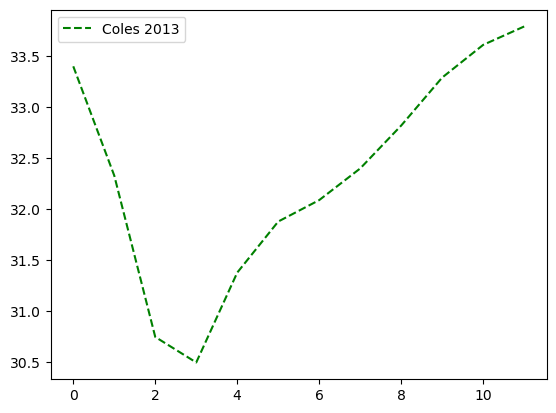

In [48]:
ssal = [33.40, 32.33, 30.75, 30.50, 31.38, 31.88, 32.09, 32.40, 32.82, 33.29, 33.61, 33.79]
plt.plot(ssal,linestyle='--',color='green',label='Coles 2013')
plt.legend()

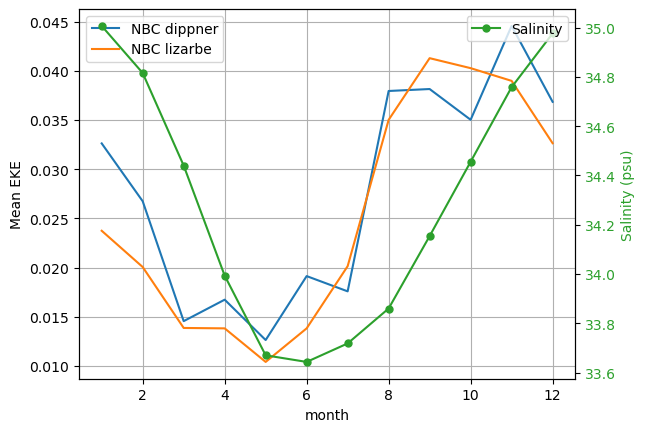

In [15]:
fig, ax1 = plt.subplots()

# Primary y-axis: EKE
seasonality(EKE).EKE.sel(lon=slice(-55,-51), lat=slice(7,10)).mean(dim=('lon','lat')).plot(
    ax=ax1, label='NBC dippner', color='C0'
)
seasonality(EKE).EKE.sel(lon=slice(-55,-40), lat=slice(2,10)).mean(dim=('lon','lat')).plot(
    ax=ax1, label='NBC lizarbe', color='C1'
)

ax1.set_ylabel('Mean EKE', color='k')
ax1.tick_params(axis='y', labelcolor='k')
ax1.legend(loc='upper left')
ax1.grid(True)

# Secondary y-axis: Salinity
ax2 = ax1.twinx()
seasonality(aa.sel(lat=slice(-2,18), lon=slice(-65,-45)).sal).mean(dim=('lon','lat')).plot(
    ax=ax2, marker='.', markersize=10, color='C2', label='Salinity'
)

ax2.set_ylabel('Salinity (psu)', color='C2')
ax2.tick_params(axis='y', labelcolor='C2')
ax2.legend(loc='upper right')

# plt.tight_layout()
plt.show()